In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv

# define and check all paths

In [11]:
TARGET = "hltprhb"

In [ ]:
load_dotenv() # load paths from .env

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
CF_OUTPUTS_DIR = Path(os.getenv("CF_OUTPUTS"))

# file / model paths
TRAIN_DATA_PATH = DATA_DIR / "05_single_target" / f"ess_ready_v2_{TARGET}_train.csv"
TEST_DATA_PATH = DATA_DIR / "05_single_target" / f"ess_ready_v2_{TARGET}_test.csv"
MODEL_PATH = MODELS_DIR / f"rf_{TARGET}_2026-03-24.pkl"

# validate paths
print("train data is file: ", TRAIN_DATA_PATH.is_file())
print("test data is file: ", TEST_DATA_PATH.is_file())
print("model path is file: ", MODEL_PATH.is_file())

train data is file:  True
test data is file:  True
model path is file:  True


# loading data, basic EDA

In [3]:
import pandas as pd

train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

In [7]:
train_df.head()

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,health,dosprt,hltprhb
0,3.0,3.0,6.0,3.0,2.0,0,36.921078,1,3.0,0.0,0
1,2.0,3.0,6.0,4.0,1.0,0,22.386314,1,2.0,7.0,0
2,4.0,4.0,6.0,6.0,1.0,0,30.846277,2,3.0,1.0,0
3,3.0,2.0,5.0,3.0,2.0,0,23.323418,1,2.0,7.0,0
4,3.0,2.0,4.0,2.0,2.0,0,30.110279,2,1.0,7.0,0


In [8]:
train_df.describe()

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,health,dosprt,hltprhb
count,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000,32883.000000
mean,3.221756,3.151720,4.357997,4.625855,1.775385,0.045099,25.914304,1.524161,2.140681,3.162455,0.214062
std,1.310048,1.110769,1.828497,2.042445,0.830707,0.207525,4.151558,0.499423,0.905202,2.593593,0.410176
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,16.003658,1.000000,1.000000,0.000000,0.000000
25%,2.000000,2.000000,3.000000,3.000000,1.000000,0.000000,22.862534,1.000000,1.000000,0.000000,0.000000
50%,3.000000,3.000000,5.000000,5.000000,2.000000,0.000000,25.535446,2.000000,2.000000,3.000000,0.000000
75%,4.000000,4.000000,6.000000,7.000000,2.000000,0.000000,28.393726,2.000000,3.000000,5.000000,0.000000
max,7.000000,7.000000,6.000000,7.000000,4.000000,1.000000,40.000000,2.000000,5.000000,7.000000,1.000000


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32883 entries, 0 to 32882
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   etfruit   32883 non-null  float64
 1   eatveg    32883 non-null  float64
 2   cgtsmok   32883 non-null  float64
 3   alcfreq   32883 non-null  float64
 4   slprl     32883 non-null  float64
 5   paccnois  32883 non-null  int64  
 6   bmi       32883 non-null  float64
 7   gndr      32883 non-null  int64  
 8   health    32883 non-null  float64
 9   dosprt    32883 non-null  float64
 10  hltprhb   32883 non-null  int64  
dtypes: float64(8), int64(3)
memory usage: 2.8 MB


### checking class distribution of datasets

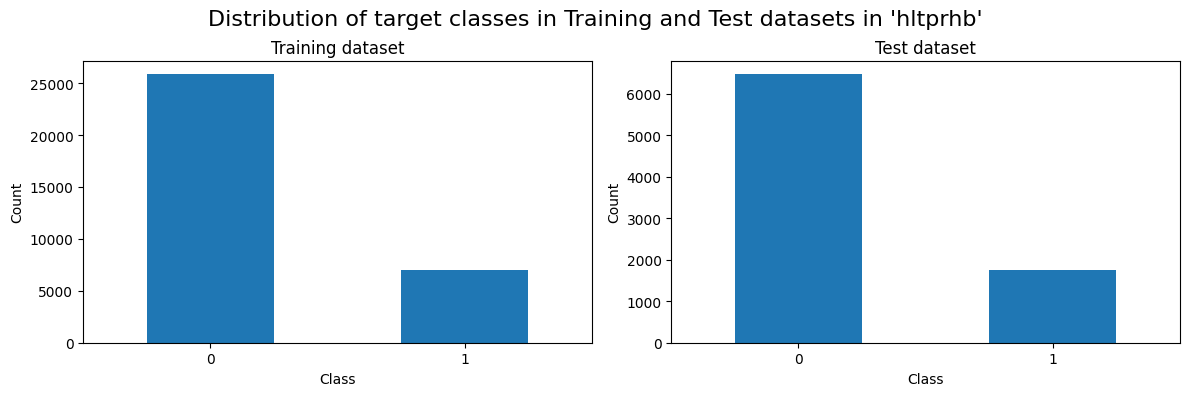

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
datasets = [("Training", train_df), ("Test", test_df)]

for ax, (name, df) in zip(axes, datasets):
    df[TARGET].value_counts().plot(kind="bar", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(f"{name} dataset")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

fig.suptitle(f"Distribution of target classes in Training and Test datasets in '{TARGET}'", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


# load and inspect predictor model

that the models features and importances seem to match what the later 
counterfactual models recommend.

In [20]:
import joblib

rf_model = joblib.load(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

importances = rf_model.feature_importances_
model_features = rf_model.feature_names_in_

print("feature names in model: ", model_features)

Loaded model: /home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/models/rf_hltprhb_2026-03-24.pkl
feature names in model:  ['etfruit' 'eatveg' 'cgtsmok' 'alcfreq' 'slprl' 'paccnois' 'bmi' 'gndr'
 'health' 'dosprt']


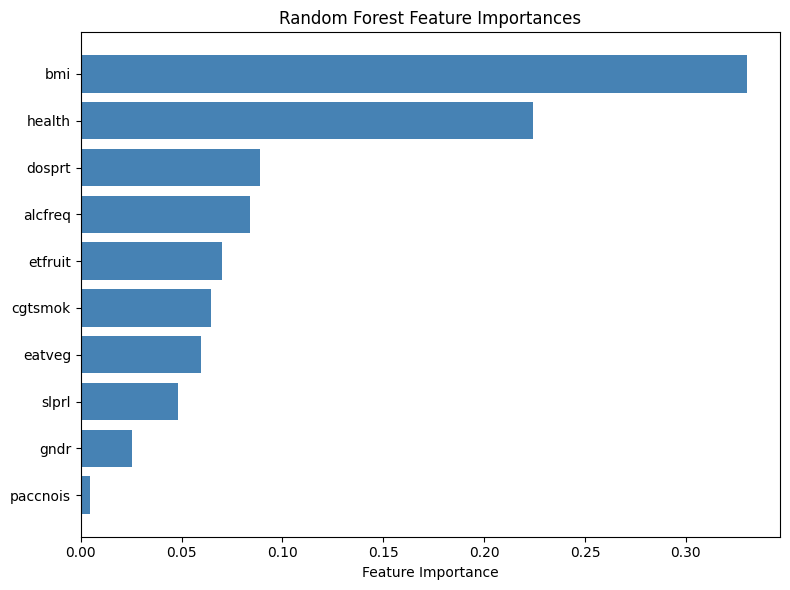

In [19]:
import numpy as np

idx = np.argsort(importances)
sorted_features = model_features[idx]
sorted_importances = importances[idx]

# Plot
plt.figure(figsize=(8, 6))
plt.barh(sorted_features, sorted_importances, color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()


# defining features

In [21]:
feature_cols = df.drop(columns=[TARGET]).columns.tolist()
print("data features == model features: ", feature_cols == model_features)

immutable = ["gndr"]
print("Immutable: ", immutable)

features_to_vary = [c for c in feature_cols if c not in immutable]
print("features_to_vary: ", features_to_vary)

data features == model features:  [ True  True  True  True  True  True  True  True  True  True]
Immutable:  ['gndr']
features_to_vary:  ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'health', 'dosprt']


# Create the DiCE-objects with test data

In [30]:
import dice_ml

dice_data = dice_ml.Data(
    dataframe=test_df,
    continuous_features=["bmi"],
    outcome_name=TARGET
)

dice_model = dice_ml.Model(
    model=rf_model,
    backend="sklearn",
    model_type="classifier"
)

explainer = dice_ml.Dice(dice_data, dice_model, method="random")

# Select datapoints to test and generate CF

In [26]:
positives = test_df[test_df[TARGET] == 1]
positives.head(20)

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,health,dosprt,hltprhb
4,3.0,3.0,5.0,6.0,2.0,0,28.344671,1,3.0,0.0,1
10,4.0,4.0,6.0,7.0,3.0,0,28.125000,2,3.0,0.0,1
14,3.0,3.0,6.0,7.0,1.0,0,22.308150,2,2.0,1.0,1
16,2.0,5.0,4.0,3.0,2.0,0,25.689562,1,2.0,1.0,1
18,4.0,4.0,6.0,4.0,1.0,0,26.297578,1,3.0,0.0,1
24,2.0,3.0,5.0,7.0,3.0,0,39.256529,2,4.0,7.0,1
30,3.0,3.0,4.0,7.0,3.0,0,31.615793,1,3.0,0.0,1
32,3.0,5.0,6.0,2.0,4.0,0,31.553659,1,2.0,5.0,1
45,4.0,4.0,1.0,6.0,1.0,0,26.838648,1,3.0,0.0,1
52,3.0,3.0,6.0,3.0,2.0,0,31.141869,1,3.0,6.0,1


Selected indexes to test: 
- [4]  normal BMI, middle high values
- [24] extremely high BMI (39.25)
- [32] high slprl (4), high dosprt(5)
- [45] low cgtsmok (1), low slpti (1)
- [86] very high BMI (37.87), high slpri(4)

In [ ]:
selected_indices = [4, 24, 32, 45, 86]

In [33]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

cf_rows = []

for idx in selected_indices:
    # Original row
    original = test_df.loc[[idx]].copy()
    original["cf_id"] = "original"
    original["query_index"] = idx

    # Query and CF
    query_instance = test_df.loc[[idx]][feature_cols]
    cf = explainer.generate_counterfactuals(
        query_instance,
        total_CFs=3,
        desired_class=0,
        features_to_vary=features_to_vary,
        stopping_threshold=0.9,
        verbose=False
    )

    # Extract CFs
    cf_df = cf.cf_examples_list[0].final_cfs_df.copy()
    cf_df["cf_id"] = [f"cf_{i+1}" for i in range(len(cf_df))]
    cf_df["query_index"] = idx

    # Add both original + CFs
    cf_rows.append(original)
    cf_rows.append(cf_df)

# Combine everything
final_cf_df = pd.concat(cf_rows, ignore_index=True)

100%|██████████| 1/1 [00:00<00:00,  2.32it/s]


In [34]:
# Reorder columns: query_index first, then cf_id, then the rest
cols = ["query_index", "cf_id"] + [c for c in final_cf_df.columns if c not in ["query_index", "cf_id"]]
final_cf_df = final_cf_df[cols]
final_cf_df

,query_index,cf_id,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,health,dosprt,hltprhb
0,4,original,3.0,3.0,5.0,6.0,2.0,0,28.344671,1,3.0,0.0,1
1,4,cf_1,3.0,3.0,5.0,6.0,2.0,0,17.369605,1,3.0,0.0,0
2,4,cf_2,3.0,3.0,5.0,6.0,2.0,0,22.369020,1,3.0,4.0,0
3,4,cf_3,3.0,3.0,5.0,6.0,4.0,0,16.495478,1,3.0,0.0,0
4,24,original,2.0,3.0,5.0,7.0,3.0,0,39.256529,2,4.0,7.0,1
5,24,cf_1,2.0,3.0,5.0,7.0,3.0,0,17.186056,2,4.0,7.0,0
6,24,cf_2,2.0,3.0,5.0,7.0,3.0,1,39.256529,2,1.0,7.0,0
7,24,cf_3,2.0,3.0,5.0,7.0,3.0,0,16.277372,2,4.0,7.0,0
8,32,original,3.0,5.0,6.0,2.0,4.0,0,31.553659,1,2.0,5.0,1
9,32,cf_1,5.0,5.0,6.0,7.0,4.0,0,31.553659,1,2.0,5.0,0


In [36]:
import datetime as dt

today = dt.datetime.today().strftime("%Y-%m-%d")
final_cf_df.to_csv(CF_OUTPUTS_DIR / f"DiCE_{TARGET}_{today}.csv", index=False)
